# Crypto perpetuals: a design matrix that is mostly one number

A perpetual future has no expiry, so nothing forces its price to converge on spot. The exchange
uses a **funding rate** instead: when the perpetual trades above spot, longs pay shorts, and the
payment scales with the gap. That gap - the **premium** - is the central quantity in this case
study, and the feature set is built largely out of it. More than half the columns carry
`premium` in the name: its level, its change over six horizons, its volatility over four, its
z-score over two windows, its quantile position over three, its rank and its cross-sectional
z-score. Six more describe the funding rate the premium produces. The remainder are a handful of
volatility estimates and two regime probabilities.

So this design matrix is not merely collinear - it is one economic quantity measured many ways,
with a small number of columns describing anything else. That makes it the clearest case in the
nine for asking what a penalty actually does. **Regularization** adds a penalty on coefficient
size to the fitting objective, and the two shapes it can take pull in opposite directions here.
**Ridge** spreads weight across the whole premium block, which is close to averaging many
measurements of the same thing. **Lasso** keeps a few columns and zeros the rest, which on a
block of near-duplicates means choosing among measurements that carry the same information - and
as the penalty rises, eventually leaving the block altogether.

Two folds, not eight: the usable history of liquid perpetual funding data is short, and
`05_evaluation` set the walk-forward schedule from what exists rather than from what would be
convenient. Every result below rests on two validation years.

**Learning objectives.** By the end of this notebook you will be able to:

- Read the set of models a case study has declared for a label, and say which estimator and
  which hyperparameters each declared name resolves to.
- Bind those declarations to the data on disk and check, before anything is fitted, that every
  configuration will be measured on the same symbols, the same dates and the same folds.
- Fit a population of models on walk-forward folds and publish one complete set of validation
  predictions per configuration.
- Read back the coefficients a run stored, count how many are non-zero along an L1 penalty
  path, and recognise the point where the path has reduced to a single column.
- Read a stable negative information coefficient for what it is - a relationship whose sign
  the training window fitted opposite to the way the validation period paid - rather than as
  an absence of one.
- Run configurations of your own into a private copy of the run log, and have them compared on
  the same footing as the ones shipped here.

**Book reference**: Chapter 11 (The ML Pipeline). Chapter 6, Section 6.7 (Search accounting and
run logging) introduces the run log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
and [`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds.

**What it writes**: one training run and one complete validation prediction set per
configuration, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`13_backtest`](13_backtest.ipynb) reads that population, runs every member against the
equal-weight baseline, and selects on validation backtest Sharpe. **Selection happens there,
not here.** This notebook ranks configurations by information coefficient to show what
regularization does to a redundant feature set; that ranking decides nothing.

In [1]:
"""Fit the declared crypto perpetuals linear-model population on the walk-forward folds."""

import re

import numpy as np
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from case_studies.research import (
    Result,
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    primary_label,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = ""

In [3]:
study = open_study(
    "crypto_perps_funding", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None
)

## 1. Which label, and which models

A label is the thing being predicted. This case study defines four in `config/setup.yaml`.
`fwd_ret_8h`, the return over the funding interval after the decision time, is the primary one -
the horizon the strategy chapters trade, and the one that lines up with when funding is actually
paid. `fwd_ret_24h` is the same idea over three intervals, and `fwd_dir_8h` and `fwd_dir_8h_3c`
are classification variants that ask for the direction rather than the size of the move.

**This notebook fits every declared label.** Each has its own training menu at
`config/training/{label}.yaml`, listing family by family the named configurations to fit for
that label, and the notebook fits the union of them. A label with no menu file has nothing
declared and nothing to fit; the labels below are the ones that declare linear models.

Fitting all four together is what makes the formulations comparable. `fwd_ret_8h` and
`fwd_dir_8h` are the same move at the same horizon, one taken as a size and one as a
direction, and whether direction is the easier thing to predict is a question about two
populations fitted on identical features and identical folds. Run one label at a time and that
comparison has to be assembled by hand from separate runs; until it is, three of the four
labels are declared and never fitted. `LABELS` restricts the run to a subset when you want one,
and defaults to everything the menus declare.

In [4]:
declared_labels(study, "linear")

('fwd_dir_8h', 'fwd_dir_8h_3c', 'fwd_ret_24h', 'fwd_ret_8h')

Each name in the menu resolves to a preset file in the shared directory
`case_studies/config/{model_type}/`, which holds that configuration's hyperparameters. The
frame below is the menu for every label above, with each name resolved to the estimator class
it names and the arguments that class is constructed with. The direction labels declare
shorter menus than the return labels, because some estimators in the return grid have no
classifier counterpart. To change what runs, edit the menu or the presets rather than this
notebook.

The grid covers the two shapes a penalty can take:

- **Ridge** penalizes the sum of squared coefficients. It shrinks correlated coefficients
  towards each other and keeps every feature, at a strength set by `alpha`. The grid steps
  `alpha` by powers of ten across ten orders of magnitude, because the useful value depends on
  the scale and the collinearity of the design matrix and neither is known in advance.
- **Lasso** penalizes the sum of absolute coefficients, which drives some of them exactly to
  zero: it selects features rather than shrinking them. **ElasticNet** mixes the two.

Lasso and ElasticNet are parameterized here by `alpha_frac` rather than a raw penalty. For any
fold there is a threshold penalty $\alpha_{\max}$ - the smallest one that zeros every
coefficient - which is computed from that fold's own data. `alpha_frac` is the fraction of it
to apply, so one declared `alpha_frac` means the same thing on every fold, while a fixed raw
penalty would mean something different on each. It is also what makes the L1 grid readable as a
path: the configurations are ordered by how far along the way to total suppression they go.

In [5]:
configs = load_model_configs(
    study,
    "linear",
    labels=LABELS or None,
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""linear""","""fwd_dir_8h""","""logistic_none""","""LogisticRegression""","""max_iter=1000, penalty=None, s…"
"""linear""","""fwd_dir_8h""","""logistic_l2_C0.001""","""LogisticRegression""","""C=0.001, max_iter=1000, solver…"
"""linear""","""fwd_dir_8h""","""logistic_l2_C0.01""","""LogisticRegression""","""C=0.01, max_iter=1000, solver=…"
"""linear""","""fwd_dir_8h""","""logistic_l2_C0.1""","""LogisticRegression""","""C=0.1, max_iter=1000, solver=l…"
"""linear""","""fwd_dir_8h""","""logistic_l2_C1.0""","""LogisticRegression""","""C=1.0, max_iter=1000, solver=l…"
…,…,…,…,…
"""linear""","""fwd_ret_8h""","""enet_f0.03""","""ElasticNet""","""alpha_frac=0.03, l1_ratio=0.5,…"
"""linear""","""fwd_ret_8h""","""enet_f0.015""","""ElasticNet""","""alpha_frac=0.015, l1_ratio=0.5…"
"""linear""","""fwd_ret_8h""","""enet_f0.35""","""ElasticNet""","""alpha_frac=0.35, l1_ratio=0.5,…"


`LABELS` and `CONFIG_NAMES` both narrow what is fitted, and a narrowed run declares a different
set of members than the canonical population does. A population is immutable once written, so
such a run must publish under its own name: on a fresh workspace it would otherwise register an
incomplete snapshot under the canonical one, and where the full population already exists the
registry refuses it. Comparing the loaded rows against the complete declared catalog catches
either knob, and says so here rather than several cells later in a message about hashes.

In [6]:
if configs.height < load_model_configs(study, "linear").height and not POPULATION_NAME:
    raise ValueError(
        f"this run fits {configs.height} of the declared configurations, so it cannot publish "
        "the canonical population; pass POPULATION_NAME to give it its own"
    )

## 2. Binding the declarations to the data

A menu entry says which estimator to fit. It does not say which feature columns exist today,
where the walk-forward folds fall, or which symbol-time pairs have both a feature row and a
label. **Resolving** a request is the step that goes and finds all of that: it reads the label
and feature files, computes the fold boundaries from the walk-forward parameters in
`config/setup.yaml`, works out the exact set of rows each fit is expected to predict, and turns
any data-dependent hyperparameter into the number it will actually use - each fold's own
$\alpha_{\max}$ times `alpha_frac`, in the case of Lasso.

Resolving reads the inputs and fits nothing, so the plan below can be inspected before any
computation starts. The three things to check in it:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row.** They are
  the width of the design matrix, the number of perpetual contracts, and the number of
  symbol-time pairs to be predicted. Every configuration here reads the same feature matrix, so
  a row that differs is a configuration being measured on a different sample from its
  neighbours, and its results are not comparable with theirs.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits
  `05_evaluation` established.
- **`validation_start` and `validation_end` bracket the development sample.** The held-out tail
  must not appear here: it is scored once, at the end of the case study, and any of it visible
  in this window would mean it had been used to choose something.

Each row also carries a `training_hash`: the identity of that computation, derived from
everything that can change its result. [`RUN_LOG.md`](../RUN_LOG.md#identity) sets out what goes
into one and what follows from it.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "validation_start",
    "validation_end",
)

config_name,feature_count,eligible_entities,eligible_rows,folds,validation_start,validation_end
str,i64,i64,i64,i64,"datetime[μs, UTC]","datetime[μs, UTC]"
"""logistic_l1_C0.01""",44,19,35280,2,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""logistic_l1_C0.1""",44,19,35280,2,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""logistic_l1_C1.0""",44,19,35280,2,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""logistic_l1_C10.0""",44,19,35280,2,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""logistic_l1_C100.0""",44,19,35280,2,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
…,…,…,…,…,…,…
"""ridge_a1000.0""",44,19,35280,2,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""ridge_a10000.0""",44,19,35280,2,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""ridge_a100000.0""",44,19,35280,2,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. fills missing feature values with the training window's median for that column, then
   standardizes each column to zero mean and unit variance - both fitted on training rows only
   and then applied to the validation rows, so nothing from the validation window reaches the
   fit,
3. fits the estimator with that fold's resolved parameters,
4. predicts the fold's validation rows.

The fold predictions are concatenated into one series covering the whole validation period,
which is what a walk-forward prediction set is: each date predicted by a model that saw only
data before it. The run then writes a `training_runs` row and the fitted coefficients, a
`prediction_sets` row and the predictions themselves, and the metrics computed from them. It
does this per configuration rather than once at the end, so an interruption costs the
configuration in flight and nothing else.

Every case study that fits linear models calls this same runner, which is what makes their
results comparable. Unlike gradient boosting or a neural network, a linear model has no
intermediate states worth scoring: there is one fit and therefore one checkpoint per
configuration, and no learning curve to plot.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
is going to produce. The list is computed from the resolved specifications before the first fit
and written down, and afterwards every member must exist and be complete. It is why a
configuration that raises fails the whole call rather than publishing a population one member
short.

**One population covers every label**, because one run fits every label and the population is
what that run declares. A population is immutable once written: registering a different set of
members under a name that already exists is refused unless the caller names the snapshot it
supersedes. A notebook that fitted one label per run under a single name would therefore
publish the first label and be refused for the second, which is what happened before this
notebook fitted them together. Everything that finished stays registered, and re-running fits
only what is missing.

In [8]:
population_name = POPULATION_NAME or "crypto_perps_funding-linear-validation-v1"
execution, population = run_model_population(study, resolved, population_name=population_name)

fitted = sum(len(item["fitted_folds"]) for item in execution.diagnostics)
reused = sum(len(item["reused_folds"]) for item in execution.diagnostics)
print(f"{len(execution.runs)} configurations: {fitted} folds fitted, {reused} reused")
print(f"population {population.name}: {len(population.members)} prediction sets")

81 configurations: 0 folds fitted, 162 reused
population crypto_perps_funding-linear-validation-v1: 81 prediction sets


`reused` is not zero on a second run. Every identity is re-derived from the inputs, the
registry already holds the matching rows, and the runner returns the stored result rather than
fitting again - so re-running this notebook unchanged costs the time it takes to read the data.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which
holds its own registry and artifacts and reads the same labels and features:

```python
study = open_study("crypto_perps_funding", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "linear", labels=["fwd_ret_8h"], config_names=["ols", "ridge_a1.0", "ridge_a3.0"]
)
requests = model_requests(study, configs)
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-linear-v1")
```

`CONFIG_NAMES` fits a subset of what the menu already declares; a name the menu does not
declare raises rather than quietly fitting fewer models than you asked for. To fit something
new, add a preset at `case_studies/config/ridge/ridge_a3.0.yaml` and list `ridge_a3.0` under
`linear:` in the label's menu. Editing an existing preset changes that configuration's
identity, so its result registers as a new row beside the old one instead of replacing it.

Give the run its own `population_name`: a name refers to one set of members permanently, and
reusing it for a different set raises. Everything downstream reads the registry rather than the
notebook, so predictions produced this way are selected and backtested on the same footing as
the ones shipped here, inside your workspace.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest, including how to
rehearse on a reduced universe first.

## 4. What came out

One row per configuration and label, read back from the registry. `ic_mean` is the **information
coefficient**: at each validation timestamp, rank the contracts by the model's prediction, rank
them by the return they went on to earn, correlate the two rankings, and average that
correlation over the validation period. It measures whether the model ranks contracts correctly,
on a scale where zero is no relationship, positive means the ranking points the right way, and
negative means it points the wrong way.

`ic_n_days` is how many validation timestamps produced a defined correlation. A model whose
coefficients collapse to nothing predicts the same value for every contract, and a constant has
no rank correlation with anything, so those timestamps would contribute nothing and the
configuration's IC would be an average over a smaller sample than its neighbours'.
`full_coverage` marks the configurations measured on all of them.

**Coverage is judged within a label, not across them.** The labels do not offer the same number
of scorable timestamps to begin with: `fwd_ret_24h` spans three funding intervals per
observation and so runs out of forward window earlier than `fwd_ret_8h`, and the two direction
labels drop the timestamps on which no contract changed sign. Comparing every configuration
against one global maximum would mark whole labels incomplete for reasons that have nothing to
do with the models. The reference is each label's own maximum.

`auc_mean_daily` reads the same predictions as a classifier would. At each timestamp, take every
pair of one contract that went up and one that went down, and count the fraction of those pairs
the model ranked in the right order; average that over the validation period. One half is the
value a coin achieves. It is computed within each timestamp and then averaged, the same shape as
`ic_mean`, so the two answer the same question: each scores how well the model ordered the
contracts against one another at a single moment, and neither is credited for the whole market
moving in a direction the model leant.

**The two are not measured on the same timestamps, and `auc_n_days` is why.** A pair needs one
contract that went up and one that went down, so a timestamp on which the whole cross-section
moved together defines no AUC at all, while a rank correlation is still defined there. That
removes 540 of the 2,189 validation timestamps, a quarter of them, and they are not a random
quarter: they are exactly the timestamps on which the whole cross-section moved together. Read
the two columns together. `full_coverage` is about `ic_n_days` alone and says nothing about the
AUC.

Both readings are shown because some of these models are fitted to the size of the return and
some are not. `fwd_dir_8h` is the direction cut from the same return at the same horizon as
`fwd_ret_8h`, and `fwd_dir_8h_3c` cuts it into three classes instead of two. This run fits all
of them, so the two formulations sit in one catalog on the same folds and the same features,
and whether predicting direction is easier than predicting size is answered from the frame
below rather than asserted.

In [9]:
catalog = (
    execution.catalog_rows.select(
        "config_name",
        "label",
        "complete",
        "ic_mean",
        "ic_std",
        "ic_n_days",
        "auc_mean_daily",
        "auc_n_days",
        "n_folds",
        "training_hash",
        "prediction_hash",
    )
    .sort(["label", "ic_mean"], descending=[False, True])
    .join(
        configs.select("config_name", "label", "model_class", "params"),
        on=["config_name", "label"],
        how="left",
    )
)

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("linear execution returned a partial prediction set")

catalog = catalog.with_columns(
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max().over("label")
)
catalog.select(
    "label",
    "config_name",
    "model_class",
    "params",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "auc_mean_daily",
    "auc_n_days",
    "full_coverage",
)

label,config_name,model_class,params,ic_mean,ic_std,ic_n_days,auc_mean_daily,auc_n_days,full_coverage
str,str,str,str,f64,f64,f64,f64,f64,bool
"""fwd_dir_8h""","""logistic_l2_C0.001""","""LogisticRegression""","""C=0.001, max_iter=1000, solver…",0.032341,0.009291,2189.0,0.51262,1649.0,true
"""fwd_dir_8h""","""logistic_l1_C0.01""","""LogisticRegression""","""C=0.01, max_iter=1000, penalty…",0.030867,0.009376,2189.0,0.513162,1649.0,true
"""fwd_dir_8h""","""logistic_l2_C0.01""","""LogisticRegression""","""C=0.01, max_iter=1000, solver=…",0.030285,0.008472,2189.0,0.51286,1649.0,true
"""fwd_dir_8h""","""logistic_l1_C0.1""","""LogisticRegression""","""C=0.1, max_iter=1000, penalty=…",0.029849,0.009618,2189.0,0.511246,1649.0,true
"""fwd_dir_8h""","""logistic_l1_C1.0""","""LogisticRegression""","""C=1.0, max_iter=1000, penalty=…",0.028936,0.009015,2189.0,0.5112,1649.0,true
…,…,…,…,…,…,…,…,…,…
"""fwd_ret_8h""","""enet_f0.5""","""ElasticNet""","""alpha_frac=0.5, l1_ratio=0.5, …",-0.04267,0.010766,2189.0,0.488646,1649.0,true
"""fwd_ret_8h""","""lasso_f0.7""","""Lasso""","""alpha_frac=0.7, max_iter=5000""",-0.042747,0.010688,2189.0,0.488472,1649.0,true
"""fwd_ret_8h""","""lasso_f0.85""","""Lasso""","""alpha_frac=0.85, max_iter=5000""",-0.042747,0.010688,2189.0,0.488472,1649.0,true


### What each label reached

One row per label, over the configurations that label actually charted. It is the frame the
comparisons below are read from, so the numbers quoted there are these and not a different
subset: `best_ic` is the best full-coverage result for that label, which is not the same as its
best result overall when a partial-coverage configuration scores higher on fewer timestamps.

In [10]:
labels_reached = (
    catalog.filter("full_coverage")
    .group_by("label")
    .agg(
        charted=pl.len(),
        scorable_timestamps=pl.col("ic_n_days").max(),
        best_config=pl.col("config_name").sort_by("ic_mean", descending=True).first(),
        best_ic=pl.col("ic_mean").max(),
        best_auc=pl.col("auc_mean_daily").max(),
        above_zero=(pl.col("ic_mean") > 0).sum(),
    )
    .sort("label")
)
labels_reached

label,charted,scorable_timestamps,best_config,best_ic,best_auc,above_zero
str,u32,f64,str,f64,f64,u32
"""fwd_dir_8h""",12,2189.0,"""logistic_l2_C0.001""",0.032341,0.513162,12
"""fwd_dir_8h_3c""",13,2189.0,"""logistic_l2_C0.001""",0.036397,null,12
"""fwd_ret_24h""",28,2187.0,"""ridge_a1.0""",-0.001004,null,0
"""fwd_ret_8h""",28,2189.0,"""enet_f0.015""",0.000838,0.509381,4


### How the penalty grid ranks

One panel per label, so the same grid can be read at each formulation. Only the configurations
measured on all of their own label's validation timestamps are charted. The zero line is the
reference that matters: a bar below it is a model whose ranking pointed the wrong way out of
sample.

**The configurations are in the same order in every panel**, that order being their ranking on
the primary label. Sorting each panel independently would put a different configuration at each
left edge and make the panels look alike whatever the numbers did.

The axis then shows something the menus decide rather than the models: the two return labels
declare penalized least-squares configurations and the two direction labels declare penalized
logistic ones, and the two sets share no names. Each panel therefore fills the half of the axis
its own menu covers and leaves the other half empty. That gap is the menu, not a missing result.

**Each panel has its own vertical scale.** The labels do not produce ICs of the same size, and a
shared scale would flatten the smaller ones to a line. Read a panel for the shape of its
ranking, and the frame above rather than the bar heights when comparing panels.

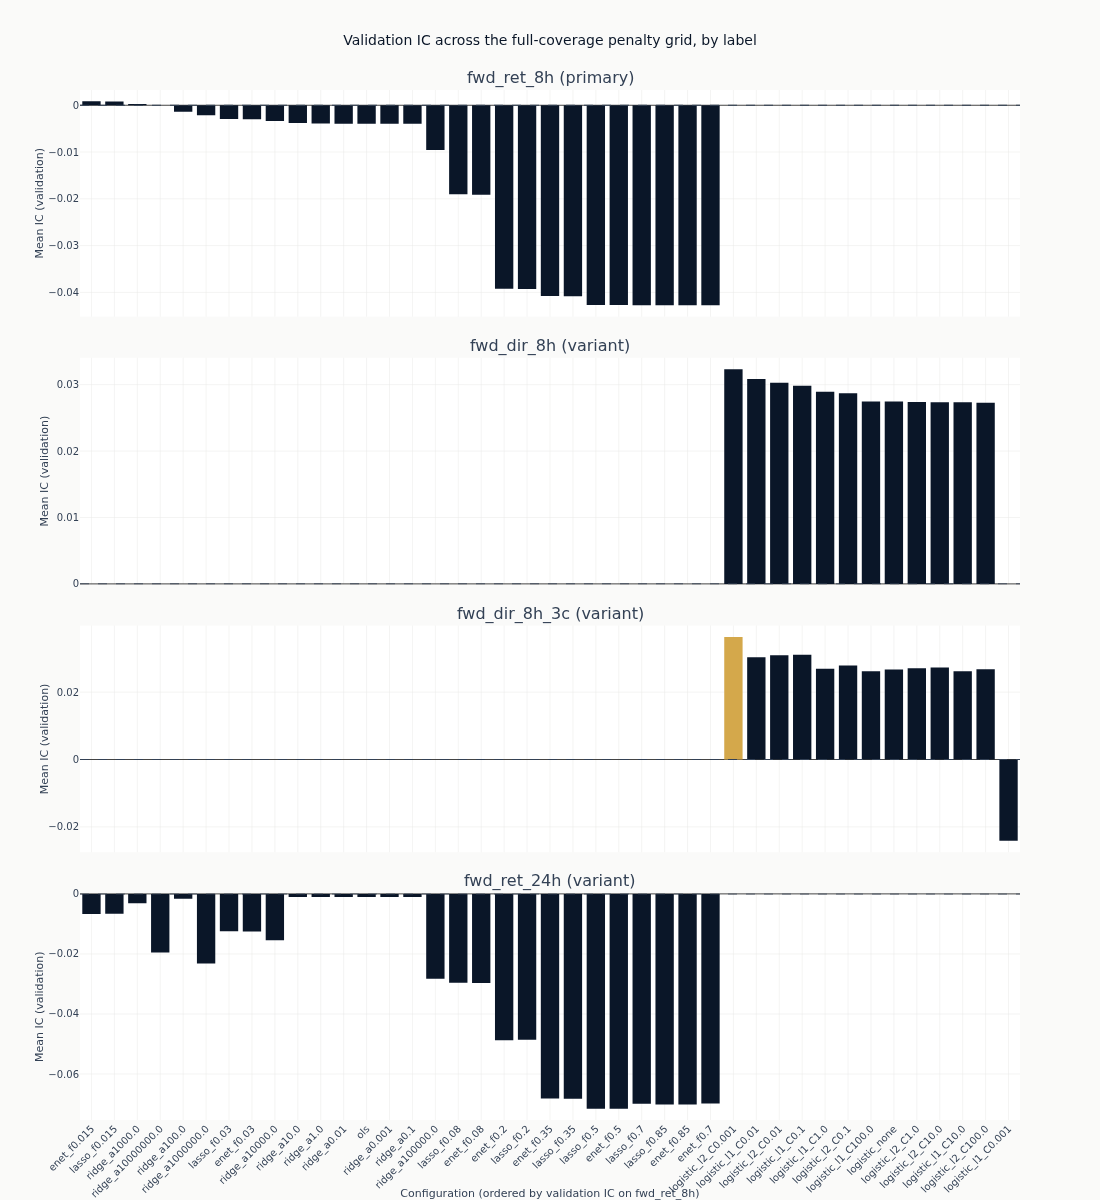

In [11]:
def compact(params: str) -> str:
    """Render declared parameters for a label: `alpha=1000000.0` reads as `alpha=1e+06`."""
    return re.sub(r"\d+\.?\d*(?:[eE][+-]?\d+)?", lambda m: f"{float(m.group()):g}", params)


primary = primary_label(study)
full = catalog.filter("full_coverage")
charted = sorted(set(full.get_column("label")))
# The primary label leads when it was fitted. A subset run that leaves it out orders the panels
# by whichever label it did fit rather than by one that is not there.
panel_labels = [label for label in [primary] if label in charted] + [
    label for label in charted if label != primary
]
order_label = panel_labels[0]
config_order = (
    full.filter(pl.col("label") == order_label)
    .sort("ic_mean", descending=True)
    .get_column("config_name")
    .to_list()
)
leader = full.sort("ic_mean", descending=True).row(0, named=True)

fig_ic = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.04,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
for row, label in enumerate(panel_labels, start=1):
    panel = full.filter(pl.col("label") == label)
    fig_ic.add_trace(
        go.Bar(
            x=panel.get_column("config_name").to_list(),
            y=panel.get_column("ic_mean").to_list(),
            marker_color=[
                COLORS["amber"]
                if (name, label) == (leader["config_name"], leader["label"])
                else COLORS["blue"]
                for name in panel.get_column("config_name")
            ],
        ),
        row=row,
        col=1,
    )
    fig_ic.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_ic.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
fig_ic.update_xaxes(
    categoryorder="array",
    categoryarray=config_order,
    tickangle=-45,
    title_text=f"Configuration (ordered by validation IC on {order_label})",
    row=len(panel_labels),
    col=1,
)
fig_ic.update_layout(
    title="Validation IC across the full-coverage penalty grid, by label",
    height=300 * len(panel_labels),
    width=1100,
    showlegend=False,
    margin=dict(t=90),
)
show_plotly_with_alt(
    fig_ic,
    "Stacked bar charts of mean validation information coefficient across the linear penalty "
    "grid, one panel per label and the configurations in the same order in each, that order "
    f"being their ranking on {order_label}. Each panel carries a dashed zero line. The highest "
    f"bar anywhere is {leader['config_name']} ({compact(leader['params'])}) on {leader['label']} "
    f"at IC {leader['ic_mean']:+.3f}, highlighted in amber.",
)

### How much of the design matrix the penalty leaves standing

The L1 grid is a path: each `alpha_frac` suppresses more coefficients than the one before it.
Counting the non-zero coefficients turns the grid into a picture of what the penalty did to the
design matrix, and it is what makes the ranking above readable. The counts come from the
coefficients each run stored, read back through `fitted_states()`, so this is what was fitted
rather than what the configuration asked for. The name printed beside each count is the feature
carrying the largest absolute coefficient on the first fold.

In [12]:
l1 = (
    # The classification menus parameterize their penalty as an inverse strength `C` rather than
    # a fraction of the fully suppressing one, so there is no alpha_frac path to trace for them
    # and the return labels are what this section covers.
    catalog.filter(pl.col("model_class").is_in(["Lasso", "ElasticNet"]))
    .with_columns(alpha_frac=pl.col("config_name").str.extract(r"_f([0-9.]+)$").cast(pl.Float64))
    .drop_nulls("alpha_frac")
    .sort("label", "alpha_frac")
)


def per_feature_magnitude(model) -> np.ndarray:
    """Largest absolute coefficient each feature carries, across a classifier's classes.

    A regression fit stores one coefficient per feature and a multi-class fit stores one row per
    class, so `coef_.ravel()` indexes past the feature names on the three-class label. Reducing
    over classes first gives one number per feature whatever the task is, which is what both the
    surviving count and the dominant feature want.
    """
    return np.abs(np.atleast_2d(np.asarray(model.coef_))).max(axis=0)


surviving, dominant = [], []
for row in l1.iter_rows(named=True):
    # A preview run's fitted states live in the preview namespace, and Result.open searches only
    # the canonical ones unless asked. While this notebook fitted one label the miss was hidden:
    # the primary label's canonical results ship with the release, so a preview lookup found them
    # there. The variant labels have no released results, so a preview run raised on the first of
    # them.
    states = Result.open(
        study, row["training_hash"], include_preview=EXECUTION_TIER == "preview"
    ).fitted_states()
    magnitudes = [per_feature_magnitude(state["model"]) for state in states]
    counts = [int(np.count_nonzero(values)) for values in magnitudes]
    surviving.append(sum(counts) / len(counts))
    first = states[0]
    dominant.append(first["feature_names"][int(np.argmax(magnitudes[0]))] if counts[0] else "none")

l1 = l1.with_columns(surviving_features=pl.Series(surviving), dominant_feature=pl.Series(dominant))
l1.select(
    "label",
    "config_name",
    "model_class",
    "alpha_frac",
    "surviving_features",
    "dominant_feature",
    "ic_mean",
)

label,config_name,model_class,alpha_frac,surviving_features,dominant_feature,ic_mean
str,str,str,f64,f64,str,f64
"""fwd_ret_24h""","""lasso_f0.015""","""Lasso""",0.015,32.5,"""garch_cond_vol""",-0.006634
"""fwd_ret_24h""","""enet_f0.015""","""ElasticNet""",0.015,33.0,"""garch_cond_vol""",-0.006671
"""fwd_ret_24h""","""lasso_f0.03""","""Lasso""",0.03,28.0,"""garch_cond_vol""",-0.012418
"""fwd_ret_24h""","""enet_f0.03""","""ElasticNet""",0.03,28.5,"""garch_cond_vol""",-0.0125
"""fwd_ret_24h""","""lasso_f0.08""","""Lasso""",0.08,17.0,"""garch_cond_vol""",-0.029564
…,…,…,…,…,…,…
"""fwd_ret_8h""","""enet_f0.5""","""ElasticNet""",0.5,2.5,"""garch_cond_vol""",-0.04267
"""fwd_ret_8h""","""lasso_f0.7""","""Lasso""",0.7,1.0,"""garch_cond_vol""",-0.042747
"""fwd_ret_8h""","""enet_f0.7""","""ElasticNet""",0.7,1.0,"""garch_cond_vol""",-0.042747


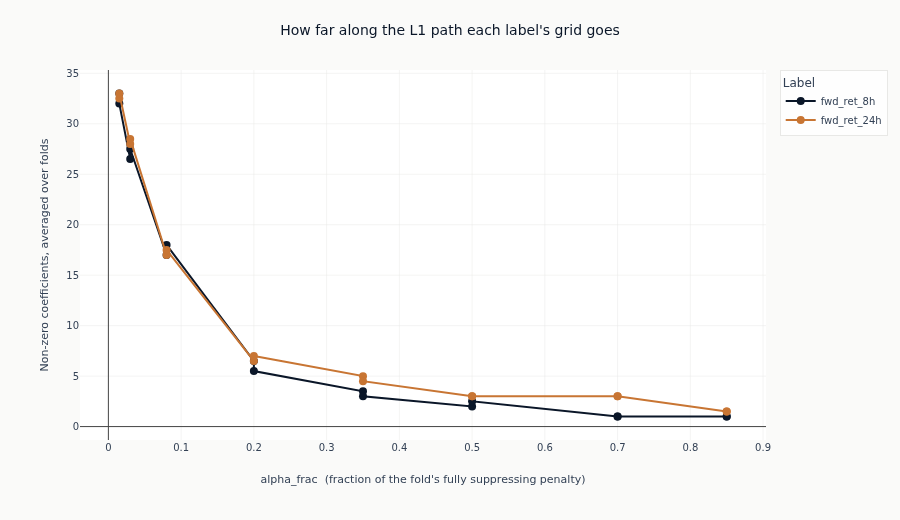

In [13]:
path_colors = [COLORS["blue"], COLORS["copper"], COLORS["amber"], COLORS["recede"]]
path_labels = [label for label in panel_labels if l1.filter(pl.col("label") == label).height]
fig_path = go.Figure()
for index, label in enumerate(path_labels):
    series = l1.filter(pl.col("label") == label)
    fig_path.add_trace(
        go.Scatter(
            x=series.get_column("alpha_frac").to_list(),
            y=series.get_column("surviving_features").to_list(),
            mode="lines+markers",
            name=label,
            line=dict(color=path_colors[index % len(path_colors)], width=2),
            marker=dict(size=8, color=path_colors[index % len(path_colors)]),
        )
    )
fig_path.update_layout(
    title="How far along the L1 path each label's grid goes",
    height=520,
    width=900,
    margin=dict(t=70),
    legend=dict(title_text="Label"),
)
fig_path.update_xaxes(title_text="alpha_frac  (fraction of the fold's fully suppressing penalty)")
fig_path.update_yaxes(title_text="Non-zero coefficients, averaged over folds")
show_plotly_with_alt(
    fig_path,
    "Line chart of the average number of non-zero coefficients against alpha_frac, one line per "
    "label. Every line falls steeply from the weakest penalty and flattens close to one across "
    "the aggressive end of the grid, well before alpha_frac reaches the value that would zero "
    "every coefficient.",
)

## 5. What to notice

**For a penalized linear model, direction is a far easier target than size, and the gap is not
small.** Read
`best_ic` down the label frame. On `fwd_ret_8h` the best configuration reaches under a
thousandth and four of twenty-eight clear zero; on `fwd_dir_8h`, which is the sign of that same
return at that same horizon, the best reaches about 0.032 and every one of the twelve
configurations is above zero. The three-class cut behaves the same way. These are the same
features, the same folds, the same contracts and the same timestamps - the only thing that
changed is whether the target is the move or its sign.

The candidate explanation is where the predictable part of the return sits. Ranking magnitudes
requires getting the size of each move roughly right, and if the cross-section of returns is
dominated by a few large moves, that ranking is largely a ranking of which contract happened to
jump. Taking the sign throws the size away and leaves a smaller quantity that may be the part
these features carry. That is a hypothesis about the label distribution and this grid does not
test it; what the grid establishes is the gap, not its cause.

What the gap is not is a change of scale. IC is a rank correlation in both cases, computed the
same way over the same timestamps against the same continuous outcome, so 0.032 against 0.0008
is a comparison of like with like. The AUC column agrees at its own scale: the best direction
configuration scores 0.513 where a coin scores 0.5, which is the pairwise reading of the same
small edge.

This is the comparison the case study was set up to make and could not make until the notebook
fitted every label in one run. It does not say the direction models are worth trading: an IC of
0.032 over fewer than 20 contracts and two folds is still small, and `13_backtest` is where it
has to survive costs and funding.

Nor does it generalize past this family. [`07_gbm`](07_gbm.ipynb) fits the same four labels with
a tree ensemble and the gap closes: both formulations land in the same place. So what is
measured above is where a weighted sum of these columns can and cannot rank, rather than a fact
about which target is predictable at this horizon.

**The L1 path reduces to one column, and the ranking stops moving exactly where it does.** Past
the middle of the `alpha_frac` grid the non-zero coefficient count reaches one, and from there
the information coefficient is identical across configurations. That is the mechanical signature
of a path that has run out: once a single coefficient is left, more penalty scales it without
changing the order it induces, and a rank correlation only sees the order. The flat tail is not
several configurations agreeing, it is one model reported several times - and reading it as
agreement is the mistake the coefficient count is here to prevent.

**The column it keeps is not a premium column.** With one coefficient left, what remains is a
volatility estimate rather than any of the many measurements of the premium. Read against the
framing at the top, that is the informative part. The premium block is wide but internally
redundant, so no single member of it stands out as a column, and a penalty that has to choose
exactly one goes elsewhere. Ridge, which spreads weight across the block instead of choosing
within it, does not face that choice and does not show the same reduction.

**A stable negative information coefficient is a relationship, not the absence of one.** The
single-column configurations post the largest-magnitude IC anywhere in this grid, on the wrong
side of zero, across every validation timestamp. The reading is that the remaining column does
order the cross-section - the training window simply fitted the sign opposite to the way the
validation period paid. Whether that is a genuine reversal or an artifact of two folds is
not something this notebook can settle, and it is the kind of question
[`11_causal_dml`](11_causal_dml.ipynb) exists for. What it does settle is that "the model found
nothing" would be the wrong summary.

**Nothing here reaches a size worth acting on, direction included.** The best return
configuration sits a small fraction of a percent above zero on two folds of validation data and
most of that grid sits below it; the direction grid is uniformly positive but at a few
hundredths, which is a real ordering and a thin one. The comparison that matters is against zero
and against the equal-weight baseline, not against the rest of the grid.

**None of this selects anything.** IC measures whether predictions rank contracts correctly, not
whether a strategy trading them makes money after costs and funding. Those are unusually far
apart in this case study: funding is a cash flow the holder receives or pays regardless of what
the price does, so a position can pay while its price prediction is wrong. Selection is on
validation backtest Sharpe over the population this notebook just published, and it happens in
[`13_backtest`](13_backtest.ipynb).

**Known limitations.** Two folds is few, and every statement above rests on two validation years
of a market whose structure changed materially over them. The IC is an average of per-timestamp
rank correlations over a cross-section of fewer than 20 contracts, so each correlation is
estimated from very little. And every number here is measured on the validation folds, which
have been read many times over by the time a case study reaches this notebook.

**Next**: [`07_gbm`](07_gbm.ipynb) asks whether gradient boosting finds structure a linear model
cannot represent at all. It is the natural next question here in particular: a tree ensemble
meets a block of near-duplicate columns by splitting on whichever one helps at each node, rather
than having to choose one for the whole model or spread weight across all of them.